In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("sci.mplstyle")

In [3]:
def tinh_he_so_backward(kappa, C, rho, N_x, N_time, L, t_max):
    h = L / (N_x - 1) # buoc luoi khong gian
    k = t_max / (N_time - 1) # buoc luoi thoi gian

    alpha = np.sqrt(kappa / (C * rho))

    eta = alpha**2 * k / h**2

    beta1 = eta / (1.0 + 2.0 * eta)
    beta2 = 1.0 / (1.0 + 2.0 * eta)

    return eta, beta1, beta2, h, k

In [4]:
def ham_ghi_file(file, dk_bai_toan): # dung de ghi thong tin quan trong ra file

    file.write(f"# {dk_bai_toan['mo_ta']}\n")
    file.write("# Backward Euler cho phuong trinh truyen nhiet 1D\n")

    file.write("#\n")

    file.write(f"# N_x    = {dk_bai_toan['N_x']}\n")
    file.write(f"# N_time = {dk_bai_toan['N_time']}\n")
    file.write(f"# L      = {dk_bai_toan['L']}\n")
    file.write(f"# t_max  = {dk_bai_toan['t_max']}\n")
    file.write(f"# h      = {dk_bai_toan['h']:.8e}\n")
    file.write(f"# k      = {dk_bai_toan['k']:.8e}\n")
    file.write(f"# eta    = {dk_bai_toan['eta']:.8e}\n")

    file.write("#\n")
    file.write(f"# {'j (t)':>8s} {'i (x)':>8s} {'t':>15s} {'x':>15s} {'u':>15s}\n")

def ham_luu_dulieu(filename, u, dk_bai_toan, skip_buoc_thoigian):
    N_x = dk_bai_toan["N_x"]
    N_time = dk_bai_toan["N_time"]
    h = dk_bai_toan["h"]
    k = dk_bai_toan["k"]

    with open(filename, "w", encoding="utf-8") as file:
        ham_ghi_file(file, dk_bai_toan)

        for j in range(N_time):
            if j % skip_buoc_thoigian != 0 and j != N_time - 1: # khi j khong chia het cho skip_buoc_thoigian thi bo qua data do va lay luon  data cuoi cung
                continue
            t = j * k

            for i in range(N_x):
                x = i * h
                file.write(f"  {j:8d} {i:8d} {t:15.6e} {x:15.6e} {u[i, j]:15.6e}\n")

            file.write("\n")

def ham_luu_hoitu(filename, bang_hoitu): # dung de luu so vong lap hoi tu

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Ket qua hoi tu cua Backward Euler\n")
        file.write(f"# {'j (t_step)':>15s} {'q (so vong lap)':>15s} {'max_err':>15s}\n")

        for j, q, max_err in bang_hoitu:
            file.write(f"  {j:15d} {q:15d} {max_err:15.6e}\n")

In [5]:
def ham_tinh_backward_euler(u,kappa,C,rho,L,t_max,N_max,tol,filename,mo_ta, cachnhiet, skip_buoc_thoigian = 20):

    N_x = u.shape[0]
    N_time = u.shape[1]

    eta, beta1, beta2, h, k = tinh_he_so_backward(
        kappa, C, rho, N_x, N_time, L, t_max
    )

    bang_hoitu = []

    # Vong lap cho thoi gian
    for j in range(1, N_time):


        # Lay nghiem cua buoc truoc lam gia tri doan ban dau
        for i in range(1, N_x - 1):
            u[i, j] = u[i, j - 1]
        
        # Neu bien la Neumann thi bien cung la an, nen can gia tri doan ban dau cho bien
        if cachnhiet == "left" or cachnhiet == "both":
            u[0, j] = u[0, j - 1]
        else:
            u[0, j] = u[0, 0]

        if cachnhiet == "right" or cachnhiet == "both":
            u[N_x - 1, j] = u[N_x - 1, j - 1]
        else:
            u[N_x - 1, j] = u[N_x - 1, 0]
        


        # Lap de giai so, voi moi buoc thoi gian thi phai lap de hoi tu tai buoc do
        for q in range(1, N_max + 1):

            u_old = u[:, j].copy()

            if cachnhiet == "left" or cachnhiet == "both": #neu cach nhiet ben trai hoac ca 2
                u[0, j] = (2.0 * beta1 * u[1, j] + beta2 * u[0, j - 1])
            else:
                u[0, j] = u[0, 0]

            for i in range(1, N_x - 1):
                u[i, j] = (
                    beta1 * (u[i + 1, j] + u[i - 1, j])
                    + beta2 * u[i, j - 1]
                )

            if cachnhiet == "right" or cachnhiet == "both": #neu cach nhiet ben phai hoac ca 2
                u[N_x - 1, j] = (2.0 * beta1 * u[N_x - 2, j] + beta2 * u[N_x - 1, j - 1])
            else:
                u[N_x - 1, j] = u[N_x - 1, 0]

            max_err = np.max(np.abs(u[:, j] - u_old)) # sai so lon nhat tai moi buoc x (lay lam dai dien cho buoc thoi gian do)

            if max_err < tol:
                bang_hoitu.append((j, q, max_err)) # ghi lai so vong lap cho moi lan hoi tu

                if np.mod(j, 50) == 0: # in ra so vong lap cho moi lan hoi tu
                    print(
                        f"j = {j}, hoi tu sau q = {q} vong lap, "
                        f"max_err = {max_err:.3e}"
                    )

                break

    dk_bai_toan = {
        "mo_ta": mo_ta,
        "N_x": N_x,
        "N_time": N_time,
        "L": L,
        "t_max": t_max,
        "h": h,
        "k": k,
        "eta": eta,
    }

    ham_luu_dulieu(filename + "_backward_result.txt", u, dk_bai_toan, skip_buoc_thoigian)

    ham_luu_hoitu(filename + "_backward_hoitu.txt", bang_hoitu)

    print("Da tinh xong Backward Euler")
    print(f"eta = {eta:.6e}")
    print(f"beta1 = {beta1:.6e}")
    print(f"beta2 = {beta2:.6e}")
    filename_print  = filename + "_backward_hoitu.txt"
    print(f"Da luu file: {filename_print}")

    return u, dk_bai_toan

In [6]:
def tao_dieu_kien_bien_bai1(N_time, N_x, L, T_ban_dau, T_trai, T_phai):

    # Ban dau: T(x, 0) = T_ban_dau
    # Hai dau: T(0, t) = T_trai, T(L, t) = T_phai

    x = np.linspace(0.0, L, N_x)
    u = np.zeros((N_x, N_time), dtype=float)

    # Dieu kien dau: T(x, 0) = T_ban_dau
    for i in range(N_x):
        u[i, 0] = T_ban_dau

    # Dieu kien bien trai: T(0, t) = T_trai
    for j in range(N_time):
        u[0, j] = T_trai

    # Dieu kien bien phai: T(L, t) = T_phai
    for j in range(N_time):
        u[N_x - 1, j] = T_phai

    # Tai t = 0, uu tien dieu kien bien tai hai dau
    u[0, 0] = T_trai
    u[N_x - 1, 0] = T_phai

    return u, x

In [7]:
N_time = 6000
N_x = 100

L = 1.0
t_max = 3000.0

T_ban_dau = 0.0
T_trai = 100.0
T_phai = 100.0

kappa = 210.0
C = 900.0
rho = 2700.0

tol  = 1e-6
N_max = 10000

# Tao dieu kien bien

u_dieukien_bien, x = tao_dieu_kien_bien_bai1(
    N_time=N_time,
    N_x=N_x,
    L=L,
    T_ban_dau=T_ban_dau,
    T_trai=T_trai,
    T_phai=T_phai,
)

In [8]:
# u,kappa,C,rho,L,t_max,N_max,tol,filename,mo_ta, skip_buoc_thoigian = 20

u, info = ham_tinh_backward_euler(
    u=u_dieukien_bien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    N_max=N_max,
    tol = tol,
    filename="BT2_cachnhiet_trai",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = "left",
    skip_buoc_thoigian = 20,
)

j = 50, hoi tu sau q = 12 vong lap, max_err = 5.149e-07
j = 100, hoi tu sau q = 11 vong lap, max_err = 8.967e-07
j = 150, hoi tu sau q = 11 vong lap, max_err = 6.036e-07
j = 200, hoi tu sau q = 11 vong lap, max_err = 4.549e-07
j = 250, hoi tu sau q = 11 vong lap, max_err = 3.649e-07
j = 300, hoi tu sau q = 11 vong lap, max_err = 3.048e-07
j = 350, hoi tu sau q = 10 vong lap, max_err = 8.805e-07
j = 400, hoi tu sau q = 10 vong lap, max_err = 7.709e-07
j = 450, hoi tu sau q = 10 vong lap, max_err = 6.860e-07
j = 500, hoi tu sau q = 10 vong lap, max_err = 6.180e-07
j = 550, hoi tu sau q = 10 vong lap, max_err = 5.623e-07
j = 600, hoi tu sau q = 10 vong lap, max_err = 5.159e-07
j = 650, hoi tu sau q = 10 vong lap, max_err = 4.767e-07
j = 700, hoi tu sau q = 10 vong lap, max_err = 4.430e-07
j = 750, hoi tu sau q = 10 vong lap, max_err = 4.140e-07
j = 800, hoi tu sau q = 10 vong lap, max_err = 3.886e-07
j = 850, hoi tu sau q = 10 vong lap, max_err = 3.662e-07
j = 900, hoi tu sau q = 10 vong 

In [9]:
u, info = ham_tinh_backward_euler(
    u=u_dieukien_bien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    N_max=N_max,
    tol = tol,
    filename="BT2_cachnhiet_phai",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = "right",
    skip_buoc_thoigian = 20,
)

j = 50, hoi tu sau q = 12 vong lap, max_err = 3.881e-07
j = 100, hoi tu sau q = 11 vong lap, max_err = 8.696e-07
j = 150, hoi tu sau q = 11 vong lap, max_err = 6.000e-07
j = 200, hoi tu sau q = 11 vong lap, max_err = 4.536e-07
j = 250, hoi tu sau q = 11 vong lap, max_err = 3.645e-07
j = 300, hoi tu sau q = 11 vong lap, max_err = 3.045e-07
j = 350, hoi tu sau q = 10 vong lap, max_err = 8.799e-07
j = 400, hoi tu sau q = 10 vong lap, max_err = 7.705e-07
j = 450, hoi tu sau q = 10 vong lap, max_err = 6.855e-07
j = 500, hoi tu sau q = 10 vong lap, max_err = 6.176e-07
j = 550, hoi tu sau q = 10 vong lap, max_err = 5.620e-07
j = 600, hoi tu sau q = 10 vong lap, max_err = 5.157e-07
j = 650, hoi tu sau q = 10 vong lap, max_err = 4.765e-07
j = 700, hoi tu sau q = 10 vong lap, max_err = 4.430e-07
j = 750, hoi tu sau q = 10 vong lap, max_err = 4.140e-07
j = 800, hoi tu sau q = 10 vong lap, max_err = 3.886e-07
j = 850, hoi tu sau q = 10 vong lap, max_err = 3.661e-07
j = 900, hoi tu sau q = 10 vong 

In [10]:
u, info = ham_tinh_backward_euler(
    u=u_dieukien_bien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    N_max=N_max,
    tol = tol,
    filename="BT2_cachnhiet_2phia",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = "both",
    skip_buoc_thoigian = 20,
)

j = 50, hoi tu sau q = 10 vong lap, max_err = 6.385e-07
j = 100, hoi tu sau q = 9 vong lap, max_err = 9.954e-07
j = 150, hoi tu sau q = 9 vong lap, max_err = 6.815e-07
j = 200, hoi tu sau q = 9 vong lap, max_err = 4.916e-07
j = 250, hoi tu sau q = 9 vong lap, max_err = 3.737e-07
j = 300, hoi tu sau q = 9 vong lap, max_err = 2.956e-07
j = 350, hoi tu sau q = 8 vong lap, max_err = 8.381e-07
j = 400, hoi tu sau q = 8 vong lap, max_err = 6.964e-07
j = 450, hoi tu sau q = 8 vong lap, max_err = 5.904e-07
j = 500, hoi tu sau q = 8 vong lap, max_err = 5.086e-07
j = 550, hoi tu sau q = 8 vong lap, max_err = 4.438e-07
j = 600, hoi tu sau q = 8 vong lap, max_err = 3.913e-07
j = 650, hoi tu sau q = 8 vong lap, max_err = 3.478e-07
j = 700, hoi tu sau q = 8 vong lap, max_err = 3.113e-07
j = 750, hoi tu sau q = 7 vong lap, max_err = 9.486e-07
j = 800, hoi tu sau q = 7 vong lap, max_err = 8.568e-07
j = 850, hoi tu sau q = 7 vong lap, max_err = 7.766e-07
j = 900, hoi tu sau q = 7 vong lap, max_err = 7.

In [11]:
def ham_doc_file(filename):
    data = np.loadtxt(filename, comments="#")

    t_raw = data[:, 2]
    x_raw = data[:, 3]
    u_raw = data[:, 4]

    x = np.unique(x_raw)
    t = np.unique(t_raw)

    N_x = len(x)
    N_time = len(t)

    print("File:", filename)
    print("N_x =", N_x)
    print("N_time =", N_time)
    print("So diem =", len(u_raw))
    print("N_x * N_time =", N_x * N_time)
    print("\n")

    if N_x * N_time != len(u_raw):
        raise ValueError("File khong phai luoi day du theo x va t")

    # file ghi theo:
    # for j in range(N_time):
    #     for i in range(N_x):
    temp = u_raw.reshape(N_time, N_x)

    return x, t, temp

In [12]:
x_backward_trai , t_backward_trai, temp_backward_trai = ham_doc_file("BT2_cachnhiet_trai_backward_result.txt")
x_backward_phai , t_backward_phai, temp_backward_phai = ham_doc_file("BT2_cachnhiet_phai_backward_result.txt")
x_backward_2phia , t_backward_2phia, temp_backward_2phia = ham_doc_file("BT2_cachnhiet_2phia_backward_result.txt")

File: BT2_cachnhiet_trai_backward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100


File: BT2_cachnhiet_phai_backward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100


File: BT2_cachnhiet_2phia_backward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100




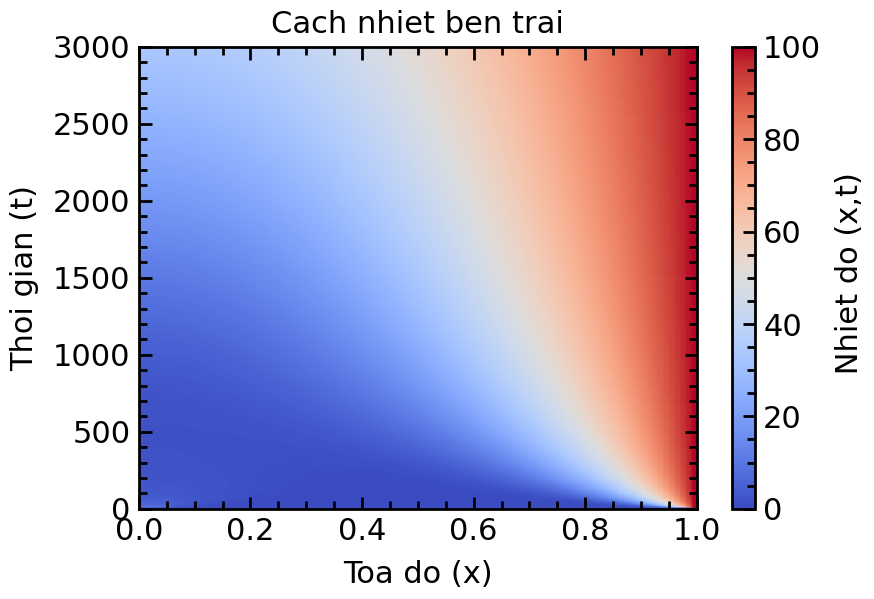

In [13]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_backward_trai,
    extent=[x_backward_trai.min(), x_backward_trai.max(), t_backward_trai.min(), t_backward_trai.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet ben trai")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_trai_backward_result.png", dpi =300)
plt.show()

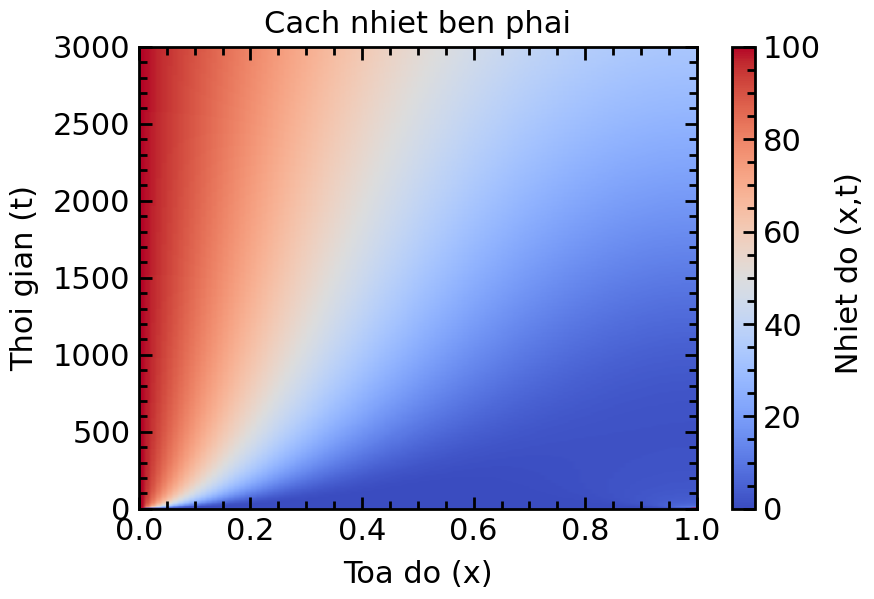

In [14]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_backward_phai,
    extent=[x_backward_phai.min(), x_backward_phai.max(), t_backward_phai.min(), t_backward_phai.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet ben phai")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_phai_backward_result.png", dpi =300)
plt.show()

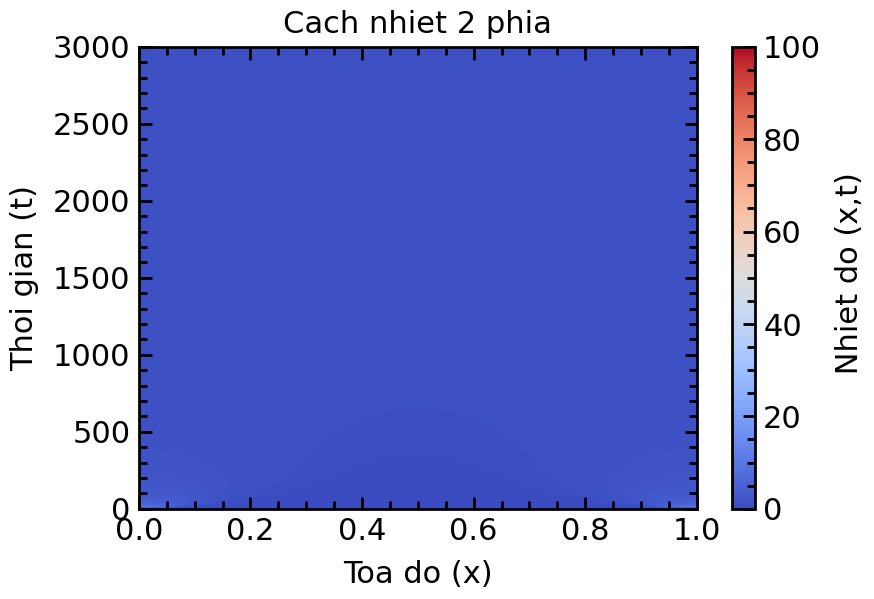

In [15]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_backward_2phia,
    extent=[x_backward_2phia.min(), x_backward_2phia.max(), t_backward_2phia.min(), t_backward_2phia.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet 2 phia")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_2phia_backward_result.png", dpi =300)
plt.show()